# Heart Disease Prediction

This project aims to predict the likelihood of heart disease based on patient clinical features.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

## 1. Load Dataset

In this section, we load the dataset and preview the data.

In [9]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Data Overview

We examine the structure of the dataset, including data types and missing values.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


We also look at summary statistics to understand the distribution of numerical features.

In [17]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

We first examine the distribution of the target variable (heart disease severity).

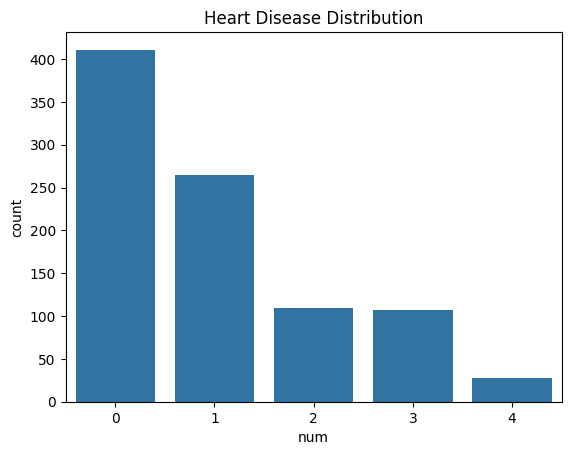

In [18]:
sns.countplot(x='num', data=df)
plt.title('Heart Disease Distribution')
plt.show()

The dataset appears to be imbalanced, with more cases in certain categories.

### 3.2 Age vs Heart Disease

We analyze how age is related to heart disease.

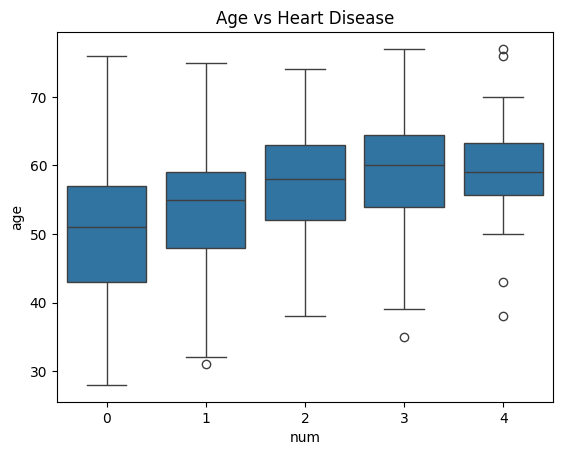

In [19]:
sns.boxplot(x='num', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()

Older individuals tend to have higher heart disease severity.

### 3.3 Sex vs Heart Disease

We explore differences between males and females.

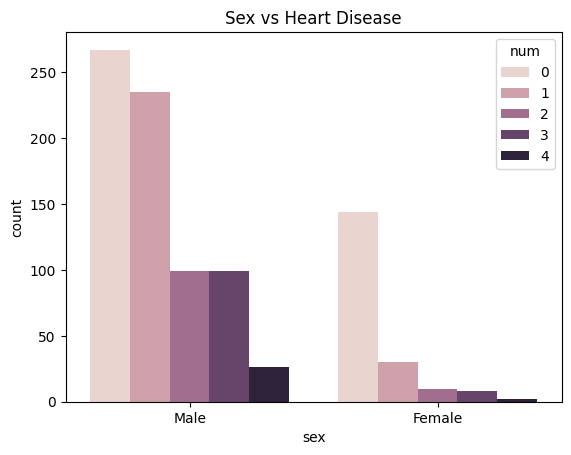

In [20]:
sns.countplot(x='sex', hue='num', data=df)
plt.title('Sex vs Heart Disease')
plt.show()

Males appear to have a higher frequency of heart disease cases.

### 3.4 Chest Pain Type vs Heart Disease

Chest pain type is an important clinical feature.

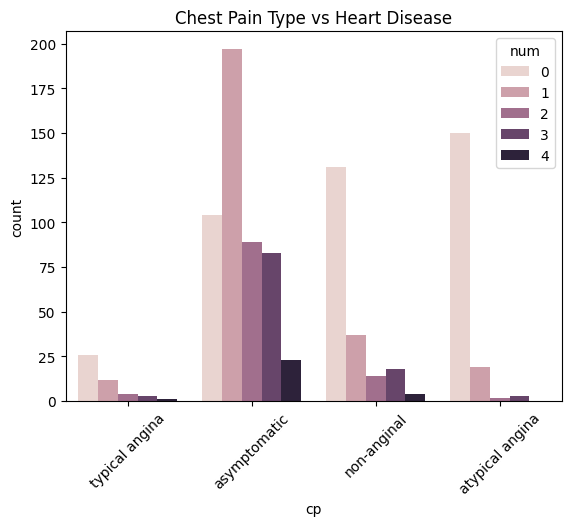

In [21]:
sns.countplot(x='cp', hue='num', data=df)
plt.xticks(rotation=45)
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

Certain chest pain types are strongly associated with heart disease.

### 3.5 Cholesterol Distribution

We examine cholesterol levels across patients.

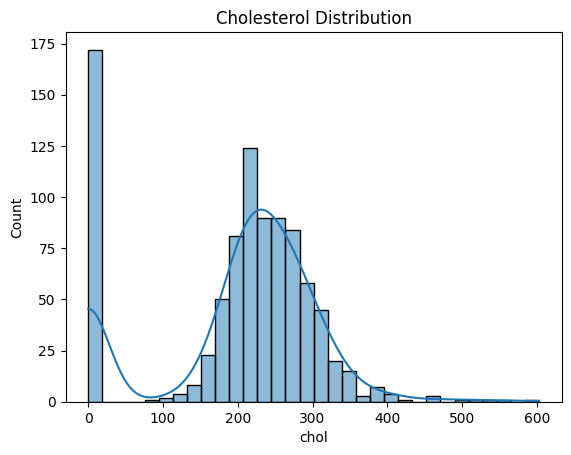

In [22]:
sns.histplot(df['chol'], kde=True)
plt.title('Cholesterol Distribution')
plt.show()

Most patients fall within a moderate cholesterol range, with some outliers.

### 3.6 Correlation Analysis

We analyze relationships between numerical variables.

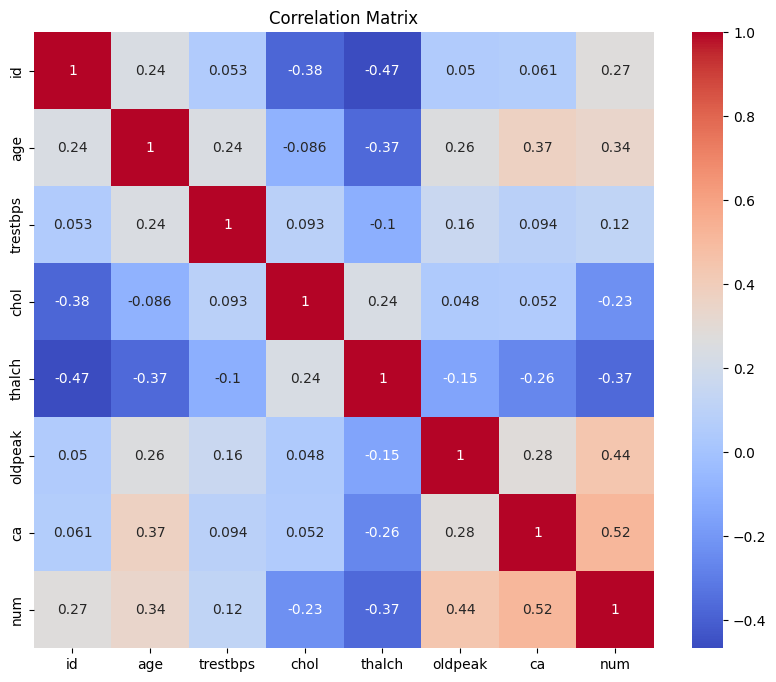

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Some variables show moderate correlations, which may be useful for modeling.

## 4. Key Insights from EDA

- The dataset is moderately imbalanced, with more patients having no heart disease.
- Age appears to be positively associated with heart disease severity.
- Male patients show a higher prevalence of heart disease compared to females.
- Chest pain type is strongly related to heart disease, especially asymptomatic cases.
- Cholesterol levels show variability but are not strongly skewed.
- Several numerical features show moderate correlations, indicating potential predictive power.

## 5. Methodology

This section outlines the steps taken to prepare the data and build predictive models for heart disease classification.

### Data Preprocessing

To prepare the dataset for modeling, missing values were removed and categorical variables were converted into numerical format. Feature scaling was also applied to ensure all variables are on a comparable scale.

In [27]:
# Remove missing values
df = df.dropna()

# Convert categorical variables to numerical (one-hot encoding)
df = pd.get_dummies(df, drop_first=True)

df.head()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,150.0,2.3,0.0,0,True,False,...,False,True,True,False,False,False,False,False,False,False
1,2,67,160.0,286.0,108.0,1.5,3.0,2,True,False,...,False,False,False,False,False,True,True,False,True,False
2,3,67,120.0,229.0,129.0,2.6,2.0,1,True,False,...,False,False,False,False,False,True,True,False,False,True
3,4,37,130.0,250.0,187.0,3.5,0.0,0,True,False,...,True,False,False,True,False,False,False,False,True,False
4,5,41,130.0,204.0,172.0,1.4,0.0,0,False,False,...,False,False,False,False,False,False,False,True,True,False


### Feature and Target Selection

The dataset was split into input features (X) and the target variable (y), where the target variable represents the presence of heart disease.

In [28]:
X = df.drop('num', axis=1)
y = df['num']

### Train-Test Split

The data was split into training and testing sets using an 80-20 ratio to evaluate model performance on unseen data.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

Standardization was applied to numerical features to improve model performance, particularly for models sensitive to feature scale.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Selection

Two models were selected for comparison:

- Logistic Regression: a simple and interpretable baseline model
- Decision Tree: a non-linear model capable of capturing complex relationships

## 6. Modeling

The selected models were trained on the training dataset and evaluated using standard classification metrics.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_acc

0.6166666666666667

Logistic Regression achieved an accuracy of 0.62 on the test set.

In [32]:
from sklearn.tree import DecisionTreeClassifier

# Train model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_acc

0.5333333333333333

Logistic Regression achieved an accuracy of 0.533 on the test set.

## 7. Model Evaluation

Model performance was further evaluated using confusion matrices to understand classification behavior.

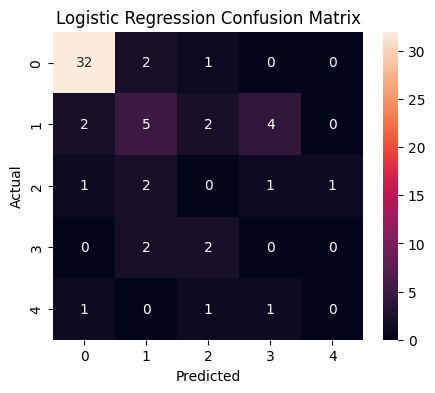

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

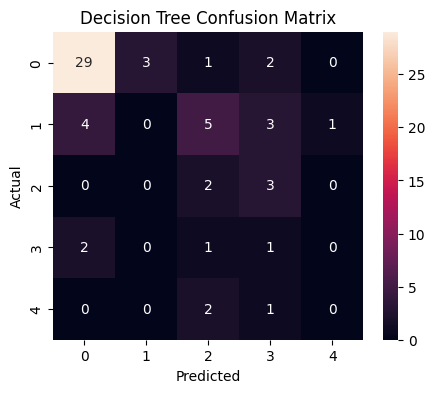

In [34]:
# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrices show that Logistic Regression makes fewer extreme misclassifications compared to Decision Tree.

The Decision Tree appears to struggle more with certain classes, likely due to overfitting on the training data.

Overall, Logistic Regression demonstrates more stable and consistent performance across different classes.

## 8. Model Comparison

The performance of both models was compared based on accuracy.

In [35]:
print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)

Logistic Regression Accuracy: 0.6166666666666667
Decision Tree Accuracy: 0.5333333333333333


The results show that Logistic Regression outperforms Decision Tree with higher accuracy (0.62 vs 0.53).

This indicates that Logistic Regression is better suited for this dataset, possibly because it generalizes better and avoids overfitting compared to the Decision Tree.

Therefore, Logistic Regression is selected as the final model.

In [36]:
from sklearn.metrics import classification_report

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree Report:")
print(classification_report(y_test, y_pred_dt))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        35
           1       0.45      0.38      0.42        13
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         3

    accuracy                           0.62        60
   macro avg       0.27      0.26      0.26        60
weighted avg       0.62      0.62      0.62        60

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        35
           1       0.00      0.00      0.00        13
           2       0.18      0.40      0.25         5
           3       0.10      0.25      0.14         4
           4       0.00      0.00      0.00         3

    accuracy                           0.53        60
   macro avg       0.22      0.30      0.24        60
weighted avg       0.51    

Additional metrics such as precision, recall, and F1-score further confirm the superior performance of Logistic Regression.

## 9. Business Insights & Recommendations

### Translating Results into Business Value

Based on the results, Logistic Regression performs better than Decision Tree in predicting heart disease, with higher accuracy and more consistent results.

In a real-world setting, this means the model can help identify patients who may be at risk earlier. Instead of relying only on manual judgment, healthcare providers can use this model as an additional tool to support their decisions.

---

### Actionable Recommendations

Hospitals or clinics could use this model during routine check-ups. Patient data can be entered into the system, and the model can flag individuals who are more likely to have heart disease.

These high-risk patients can then be recommended for further tests or closer monitoring. This can help doctors focus more on patients who need attention the most.

---

### Implementation Considerations

To make this work in practice, the model should be connected to existing healthcare systems, such as electronic health records (EHR).

It is also important to update the model regularly with new data to maintain its accuracy. In addition, the model should be used as a support tool rather than replacing medical professionals.

---

### Expected Business Impact

Using this model can help detect heart disease earlier, which may reduce treatment costs and improve patient outcomes.

It can also help healthcare providers allocate resources more efficiently by focusing on high-risk patients.

Overall, this model provides a simple but practical way to support early detection of heart disease in a healthcare setting.

## 10. Ethics & Responsible AI

### Potential Biases Identified

One potential concern in this dataset is that certain groups may be underrepresented, such as specific age ranges or female patients. This could lead the model to perform better on some groups than others.

For example, if the dataset contains more male patients, the model may be more accurate for males but less reliable for females.

---

### Fairness Considerations

It is important to ensure that the model provides fair predictions across different groups. In healthcare, unfair predictions could lead to unequal treatment or missed diagnoses.

To address this, the model should be evaluated across different demographic groups (such as gender or age) to check for performance differences.

---

### Privacy and Security Implications

Since this project involves health-related data, privacy is a major concern. Patient data must be handled carefully and should not be exposed or misused.

In real-world applications, strong data protection measures (such as encryption and access control) should be implemented to ensure patient confidentiality.

---

### Recommendations for Responsible Deployment

The model should be used as a decision-support tool rather than replacing medical professionals.

Additionally, regular monitoring and updates are necessary to maintain fairness and accuracy over time.

Clear communication is also important so that healthcare providers understand the model’s limitations and do not rely on it blindly.

## 11. Conclusion & Future Work

### Summary of Achievements

In this project, we explored a heart disease dataset and performed exploratory data analysis to understand key patterns and relationships.

We then applied two classification models, Logistic Regression and Decision Tree, to predict the presence of heart disease. Based on the results, Logistic Regression achieved better performance and was selected as the final model.

---

### Limitations of the Current Approach

One limitation of this project is the relatively small dataset, which may affect the model’s ability to generalize to new data.

In addition, only a limited number of models were tested. There may be other models that could achieve better performance.

---

### Suggestions for Future Improvements

Future work could include trying more advanced models such as Random Forest or Gradient Boosting to improve prediction accuracy.

It would also be helpful to use a larger and more diverse dataset to make the model more robust.

---

### Lessons Learned

This project helped demonstrate the importance of data preprocessing, model selection, and evaluation in building a predictive model.

It also showed that simpler models like Logistic Regression can sometimes perform better than more complex models, depending on the dataset.

Overall, this project provided a practical understanding of how machine learning can be applied to real-world healthcare problems.